# 03 — SAR Data Pipeline: Building the LR/HR Training Dataset

**Goal:** Build a dataset of ~15,000 Low-Resolution / High-Resolution SAR patch pairs without downloading the full 1.5 TB of raw imagery.  
Instead, each large remote GeoTIFF is accessed via HTTP range requests (`rasterio` windowed reads) and only the requested pixel rectangle is streamed.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pystac
import rasterio
from rasterio.windows import Window
from rasterio.transform import Affine
from concurrent.futures import ThreadPoolExecutor, as_completed
from skimage.transform import resize as sk_resize
from tqdm import tqdm

warnings.filterwarnings('ignore')

print(f"rasterio : {rasterio.__version__}")
print(f"numpy    : {np.__version__}")

rasterio : 1.5.0
numpy    : 2.0.2


## Configuration

All tuneable parameters are defined here so they can be adjusted without hunting through the code.

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
COLLECTION_URL = (
    "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/"
    "capella-open-data-ieee-data-contest/collection.json"
)
CSV_PATH   = Path("../data/Capella_IEEE_DataContest_2026.csv")
CACHE_CSV  = Path("../data/geo_asset_urls.csv")   # resolved URL cache
OUT_DIR    = Path("../data/dataset")

# ── Patch geometry ───────────────────────────────────────────────────────────
PATCH_HR           = 512    # HR patch side length in pixels
SCALE              = 4      # LR = PATCH_HR // SCALE in each dimension → 128 px
PATCH_LR           = PATCH_HR // SCALE

# ── Sampling ─────────────────────────────────────────────────────────────────
PATCHES_PER_IMAGE  = 20     # random patches to extract per SAR scene
BORDER_FRAC        = 0.05   # inset fraction from image edges to avoid artefacts
MAX_ZERO_FRAC      = 0.20   # skip a patch if more than 20% of pixels are zero
SEED               = 42

# ── Concurrency ──────────────────────────────────────────────────────────────
N_URL_WORKERS      = 16     # threads for STAC JSON resolution
N_IMG_WORKERS      = 6      # threads for image-level pipeline (stream + save)

print(f"HR patch : {PATCH_HR} x {PATCH_HR} px  (uint16, native Capella amplitude)")
print(f"LR patch : {PATCH_LR} x {PATCH_LR} px  (float32, {SCALE}x bicubic downscale)")
print(f"Patches per image : {PATCHES_PER_IMAGE}")
print(f"Output directory  : {OUT_DIR.resolve()}")

HR patch : 512 x 512 px  (uint16, native Capella amplitude)
LR patch : 128 x 128 px  (float32, 4x bicubic downscale)
Patches per image : 20
Output directory  : /Users/hoangvinh.nguyen2@iqvia.com/self/hv/term_project/data/dataset


## Step 1 — Parse STAC Metadata

In [3]:
# ── STAC helper functions (adapted from notebook 02) ─────────────────────────

STAC_BASE = (
    "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/"
    "capella-open-data-by-datetime"
)


def stac_json_url(stac_id: str) -> str:
    """
    Reconstruct the STAC item JSON URL from a stac_id string.

    The stac_id encodes the start datetime at token index 5:
        CAPELLA_C13_SP_GEO_HH_20250902021114_20250902021153
                              ^^^^^^^^^^^^^^
                              YYYYMMDDHHMMSS
    """
    date_str = stac_id.split("_")[5]
    yyyy, mm, dd = date_str[:4], date_str[4:6], date_str[6:8]
    return (
        f"{STAC_BASE}/"
        f"capella-open-data-{yyyy}/"
        f"capella-open-data-{yyyy}-{mm}/"
        f"capella-open-data-{yyyy}-{mm}-{dd}/"
        f"{stac_id}/{stac_id}.json"
    )


def get_asset_url(stac_id: str, asset_key: str = "HH") -> str | None:
    """Fetch a STAC item JSON and return the href of the requested asset."""
    try:
        item = pystac.Item.from_file(stac_json_url(stac_id))
        if asset_key in item.assets:
            return item.assets[asset_key].href
    except Exception:
        pass
    return None


print("STAC helper functions defined.")

STAC helper functions defined.


In [4]:
# ── Load the catalogue and filter to GEO products ────────────────────────────
df     = pd.read_csv(CSV_PATH)
geo_df = df[df['product_type'] == 'GEO'].copy().reset_index(drop=True)
print(f"Total catalogue items : {len(df)}")
print(f"GEO items (amplitude) : {len(geo_df)}")

# ── Resolve asset URLs (with cache) ──────────────────────────────────────────
if CACHE_CSV.exists():
    print(f"\nLoading cached asset URLs from {CACHE_CSV} ...")
    cache = pd.read_csv(CACHE_CSV)
    geo_df = geo_df.merge(cache[['stac_id', 'asset_url']], on='stac_id', how='left')
    n_missing = geo_df['asset_url'].isna().sum()
    print(f"Cached: {len(geo_df) - n_missing}  |  missing: {n_missing}")
else:
    geo_df['asset_url'] = None
    n_missing = len(geo_df)
    print(f"No cache found — will resolve all {n_missing} URLs from STAC.")

# Resolve only those still missing
to_resolve = geo_df[geo_df['asset_url'].isna()].copy()

if len(to_resolve) > 0:
    print(f"\nResolving {len(to_resolve)} asset URLs (this may take a few minutes) ...")

    def _resolve(args):
        idx, stac_id = args
        return idx, get_asset_url(stac_id)

    tasks = [(row.name, row['stac_id']) for _, row in to_resolve.iterrows()]
    with ThreadPoolExecutor(max_workers=N_URL_WORKERS) as pool:
        futures = {pool.submit(_resolve, t): t[0] for t in tasks}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Resolving URLs"):
            idx, url = fut.result()
            geo_df.at[idx, 'asset_url'] = url

    # Save updated cache
    geo_df[['stac_id', 'asset_url']].to_csv(CACHE_CSV, index=False)
    print(f"URL cache saved to {CACHE_CSV}")

valid_df = geo_df.dropna(subset=['asset_url']).reset_index(drop=True)
print(f"\nValid asset URLs resolved : {len(valid_df)} / {len(geo_df)}")
print(f"Projected patch pairs    : {len(valid_df) * PATCHES_PER_IMAGE:,}")

Total catalogue items : 1582
GEO items (amplitude) : 791
No cache found — will resolve all 791 URLs from STAC.

Resolving 791 asset URLs (this may take a few minutes) ...


Resolving URLs: 100%|██████████| 791/791 [00:46<00:00, 16.92it/s]

URL cache saved to ../data/geo_asset_urls.csv

Valid asset URLs resolved : 760 / 791
Projected patch pairs    : 15,200


### Quick sanity check — inspect one asset URL

In [5]:
sample_row = valid_df.iloc[0]
sample_url = sample_row['asset_url']

print(f"Scene   : {sample_row['stac_id']}")
print(f"URL     : {sample_url[:90]}...")

with rasterio.open(sample_url) as src:
    H, W = src.height, src.width
    print(f"Shape   : {H} rows x {W} cols")
    print(f"CRS     : {src.crs}")
    print(f"dtype   : {src.dtypes[0]}")
    print(f"Bands   : {src.count}")
    pixel_m = abs(src.transform.a)
    print(f"Pixel   : {pixel_m:.3f} m")
    print(f"Scene   : {W * pixel_m / 1000:.1f} km x {H * pixel_m / 1000:.1f} km")

Scene   : CAPELLA_C13_SP_GEO_HH_20251105111537_20251105111546
URL     : https://capella-open-data.s3.amazonaws.com/data/2025/11/5/CAPELLA_C13_SP_GEO_HH_2025110511...
Shape   : 33884 rows x 32144 cols
CRS     : EPSG:32610
dtype   : uint16
Bands   : 1
Pixel   : 0.341 m
Scene   : 11.0 km x 11.6 km


## Step 2 — Core Helper Functions

These functions handle the three main operations: streaming, downsampling, and saving.

In [6]:
# ── 2a. Stream a patch from a remote COG ─────────────────────────────────────

def read_sar_patch(
    url: str,
    col_off: int,
    row_off: int,
    width: int = 512,
    height: int = 512,
    band: int = 1,
) -> tuple[np.ndarray, dict]:
    """
    Stream a rectangular pixel window from a remote Cloud-Optimised GeoTIFF.

    Only the bytes covering the requested window are fetched over HTTPS
    (GDAL HTTP range request).  No full-file download is needed.

    Parameters
    ----------
    url      : HTTPS URL of the COG.
    col_off  : Left edge of the window (x, in pixels from the left of the image).
    row_off  : Top  edge of the window (y, in pixels from the top  of the image).
    width    : Window width  in pixels.
    height   : Window height in pixels.
    band     : Band index (1-based).  GEO products have a single HH band.

    Returns
    -------
    patch    : 2-D numpy array of shape (height, width) with the original dtype.
    meta     : Dict containing CRS, full image shape, and the window geotransform.
    """
    with rasterio.open(url) as src:
        win   = Window(col_off, row_off, width, height)
        patch = src.read(band, window=win)
        meta  = {
            'crs'              : src.crs,
            'full_shape'       : (src.height, src.width),
            'window_transform' : src.window_transform(win),
            'dtype'            : src.dtypes[0],
        }
    return patch, meta


print("read_sar_patch defined.")

read_sar_patch defined.


In [7]:
# ── 2b. Bicubic downsampling ──────────────────────────────────────────────────

def downsample_patch(hr: np.ndarray, scale: int = 4) -> np.ndarray:
    """
    Simulate a Low-Resolution patch from an HR SAR amplitude patch.

    Uses bicubic interpolation (order=3) with anti-aliasing to avoid
    aliasing artefacts — the same degradation model used in most SR literature.

    The LR patch has shape (H // scale, W // scale) and dtype float32.
    Values are in the same amplitude range as the HR uint16 input;
    normalisation to [0, 1] is done in the training pipeline.

    Parameters
    ----------
    hr    : 2-D uint16 array — the HR patch.
    scale : Downsampling factor (default 4 → 512 px becomes 128 px).

    Returns
    -------
    lr    : 2-D float32 array of shape (H // scale, W // scale).
    """
    lr_h, lr_w = hr.shape[0] // scale, hr.shape[1] // scale
    lr = sk_resize(
        hr.astype(np.float32),
        (lr_h, lr_w),
        order=3,              # cubic B-spline (bicubic)
        anti_aliasing=True,   # low-pass filter before decimation
        preserve_range=True,  # keep amplitude values in uint16 range
    )
    return lr.astype(np.float32)


print("downsample_patch defined.")

downsample_patch defined.


In [8]:
# ── 2c. Save an HR/LR pair as compressed GeoTIFFs ────────────────────────────

def save_patch_pair(
    hr: np.ndarray,
    lr: np.ndarray,
    meta: dict,
    scale: int,
    hr_path: Path,
    lr_path: Path,
) -> None:
    """
    Write an HR/LR patch pair as LZW-compressed single-band GeoTIFFs.

    HR file  : uint16, same dtype as the raw Capella amplitude.
    LR file  : float32, output of bicubic downsampling.

    The LR geotransform is derived from the HR window transform by scaling
    the pixel spacing by the downsampling factor, so both files share the
    same geographic footprint but at different resolutions.

    Parameters
    ----------
    hr       : 2-D HR array of shape (PATCH_HR, PATCH_HR).
    lr       : 2-D LR array of shape (PATCH_LR, PATCH_LR).
    meta     : Dict returned by read_sar_patch.
    scale    : Downsampling factor (used to rescale the LR pixel spacing).
    hr_path  : Destination path for the HR GeoTIFF.
    lr_path  : Destination path for the LR GeoTIFF.
    """
    win_tf = meta['window_transform']
    crs    = meta['crs']

    # HR — preserve original uint16 amplitude values
    with rasterio.open(
        hr_path, 'w',
        driver='GTiff',
        height=hr.shape[0], width=hr.shape[1],
        count=1, dtype=hr.dtype,
        crs=crs, transform=win_tf,
        compress='lzw',
    ) as dst:
        dst.write(hr[np.newaxis, :, :])

    # LR — float32; pixel spacing is `scale` times larger than HR
    lr_tf = Affine(
        win_tf.a * scale, win_tf.b, win_tf.c,
        win_tf.d, win_tf.e * scale, win_tf.f,
    )
    with rasterio.open(
        lr_path, 'w',
        driver='GTiff',
        height=lr.shape[0], width=lr.shape[1],
        count=1, dtype='float32',
        crs=crs, transform=lr_tf,
        compress='lzw',
    ) as dst:
        dst.write(lr[np.newaxis, :, :])


print("save_patch_pair defined.")

save_patch_pair defined.


In [9]:
# ── 2d. Random patch origin sampler ──────────────────────────────────────────

def sample_patch_origins(
    H: int,
    W: int,
    patch_size: int,
    n: int,
    rng: np.random.Generator,
    border_frac: float = 0.05,
) -> list[tuple[int, int]]:
    """
    Sample `n` random (col_off, row_off) patch origins within an image.

    A fractional inset is applied on all four sides to avoid the zero-padded
    borders that are common in SAR GEO products.  Patches must fit entirely
    inside the valid sampling region.

    Parameters
    ----------
    H, W        : Full image dimensions in pixels.
    patch_size  : Side length of the square patch to extract.
    n           : Number of origins to sample.
    rng         : NumPy random Generator (for reproducibility).
    border_frac : Fraction of H / W to exclude from each edge.

    Returns
    -------
    List of (col_off, row_off) tuples, empty if the image is too small.
    """
    inset_r = int(H * border_frac)
    inset_c = int(W * border_frac)

    row_min = inset_r
    row_max = H - patch_size - inset_r
    col_min = inset_c
    col_max = W - patch_size - inset_c

    if row_max <= row_min or col_max <= col_min:
        return []   # image too small for even one patch with this inset

    rows = rng.integers(row_min, row_max, size=n)
    cols = rng.integers(col_min, col_max, size=n)
    return list(zip(cols.tolist(), rows.tolist()))   # (col_off, row_off)


print("sample_patch_origins defined.")

sample_patch_origins defined.


## Step 3 — Main Pipeline

The pipeline is parallelised at the **image level**: each worker thread handles one SAR scene end-to-end (header read, patch sampling, streaming, downsampling, saving).  This amortises the HTTPS connection overhead while keeping the number of concurrent S3 connections bounded.

**Resume support:** If a patch pair already exists on disk it is skipped, so the pipeline can be interrupted and restarted without data loss.

In [10]:
# ── Create output directory ───────────────────────────────────────────────────
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUT_DIR.resolve()}")

# ── Pre-compute the global patch index ranges so each image gets a fixed
#    block of patch IDs, enabling deterministic resume support. ─────────────────
#
#    image i  →  patches  [i * PATCHES_PER_IMAGE, (i+1) * PATCHES_PER_IMAGE)

total_planned = len(valid_df) * PATCHES_PER_IMAGE
print(f"Total patches planned : {total_planned:,}")
print(f"Files to create       : {total_planned * 2:,} (HR + LR for each pair)")

Output directory: /Users/hoangvinh.nguyen2@iqvia.com/self/hv/term_project/data/dataset
Total patches planned : 15,200
Files to create       : 30,400 (HR + LR for each pair)


In [11]:
# ── Per-image worker function ─────────────────────────────────────────────────

def process_image(img_idx: int, row: pd.Series) -> dict:
    """
    Full pipeline for a single SAR scene.

    1. Open image header to get dimensions (no pixel data transferred).
    2. Sample PATCHES_PER_IMAGE random origins.
    3. For each origin:
       a. Stream the HR window.
       b. Check for nodata (skip if > MAX_ZERO_FRAC of pixels are zero).
       c. Bicubic downsample to LR.
       d. Save HR and LR as GeoTIFFs.

    Returns a summary dict with counts of saved, skipped, and failed patches.
    """
    url         = row['asset_url']
    base_idx    = img_idx * PATCHES_PER_IMAGE
    rng         = np.random.default_rng(SEED + img_idx)   # per-image RNG

    result = {'saved': 0, 'skipped': 0, 'failed': 0}

    # ── Open header (bytes 0..N of the COG, no tiles fetched) ────────────────
    try:
        with rasterio.open(url) as src:
            H, W = src.height, src.width
    except Exception as exc:
        result['failed'] = PATCHES_PER_IMAGE
        return result

    origins = sample_patch_origins(H, W, PATCH_HR, PATCHES_PER_IMAGE, rng, BORDER_FRAC)
    if not origins:
        result['skipped'] = PATCHES_PER_IMAGE
        return result

    for local_i, (col_off, row_off) in enumerate(origins):
        patch_idx = base_idx + local_i
        hr_path   = OUT_DIR / f"patch_{patch_idx:06d}_HR.tif"
        lr_path   = OUT_DIR / f"patch_{patch_idx:06d}_LR.tif"

        # Resume: skip if both files already exist
        if hr_path.exists() and lr_path.exists():
            result['saved'] += 1
            continue

        try:
            hr, meta = read_sar_patch(url, col_off, row_off, PATCH_HR, PATCH_HR)

            # Quality gate: reject nodata-heavy patches
            if hr.max() == 0 or (hr == 0).mean() > MAX_ZERO_FRAC:
                result['skipped'] += 1
                continue

            lr = downsample_patch(hr, scale=SCALE)
            save_patch_pair(hr, lr, meta, SCALE, hr_path, lr_path)
            result['saved'] += 1

        except Exception:
            result['failed'] += 1

    return result


print("process_image defined.")

process_image defined.


In [12]:
# ── Run the pipeline ──────────────────────────────────────────────────────────
#
# Images are processed in parallel (N_IMG_WORKERS threads).
# A progress bar tracks completed images; per-image counts are aggregated.

total_saved   = 0
total_skipped = 0
total_failed  = 0

tasks = [
    (img_idx, row)
    for img_idx, (_, row) in enumerate(valid_df.iterrows())
]

with ThreadPoolExecutor(max_workers=N_IMG_WORKERS) as pool:
    futures = {
        pool.submit(process_image, img_idx, row): img_idx
        for img_idx, row in tasks
    }
    with tqdm(total=len(futures), desc="SAR scenes", unit="scene") as pbar:
        for fut in as_completed(futures):
            r = fut.result()
            total_saved   += r['saved']
            total_skipped += r['skipped']
            total_failed  += r['failed']
            pbar.set_postfix(
                saved=total_saved,
                skip=total_skipped,
                fail=total_failed,
            )
            pbar.update(1)

print(f"\nPipeline complete")
print(f"  Pairs saved   : {total_saved:,}")
print(f"  Patches skipped (nodata / small image) : {total_skipped:,}")
print(f"  Failures      : {total_failed:,}")

SAR scenes: 100%|██████████| 760/760 [56:18<00:00,  4.44s/scene, fail=0, saved=6030, skip=9170]  


Pipeline complete
  Pairs saved   : 6,030
  Patches skipped (nodata / small image) : 9,170
  Failures      : 0


## Step 4 — Verification & Dataset Summary

Count files, estimate disk usage, and display a few HR/LR sample pairs to confirm the pipeline produced correct output.

In [13]:
import matplotlib.pyplot as plt

# ── File counts and disk usage ────────────────────────────────────────────────
hr_files = sorted(OUT_DIR.glob("*_HR.tif"))
lr_files = sorted(OUT_DIR.glob("*_LR.tif"))

n_hr = len(hr_files)
n_lr = len(lr_files)

total_bytes = (
    sum(f.stat().st_size for f in hr_files)
    + sum(f.stat().st_size for f in lr_files)
)

avg_hr_kb = (
    sum(f.stat().st_size for f in hr_files) / max(n_hr, 1) / 1024
)
avg_lr_kb = (
    sum(f.stat().st_size for f in lr_files) / max(n_lr, 1) / 1024
)

print("Dataset Summary")
print("=" * 40)
print(f"HR files          : {n_hr:,}")
print(f"LR files          : {n_lr:,}")
print(f"Matched pairs     : {min(n_hr, n_lr):,}")
print(f"Total disk usage  : {total_bytes / 1e9:.2f} GB")
print(f"Avg HR file size  : {avg_hr_kb:.1f} KB")
print(f"Avg LR file size  : {avg_lr_kb:.1f} KB")
print(f"Output directory  : {OUT_DIR.resolve()}")

Dataset Summary
HR files          : 6,030
LR files          : 6,030
Matched pairs     : 6,030
Total disk usage  : 3.57 GB
Avg HR file size  : 509.3 KB
Avg LR file size  : 69.0 KB
Output directory  : /Users/hoangvinh.nguyen2@iqvia.com/self/hv/term_project/data/dataset


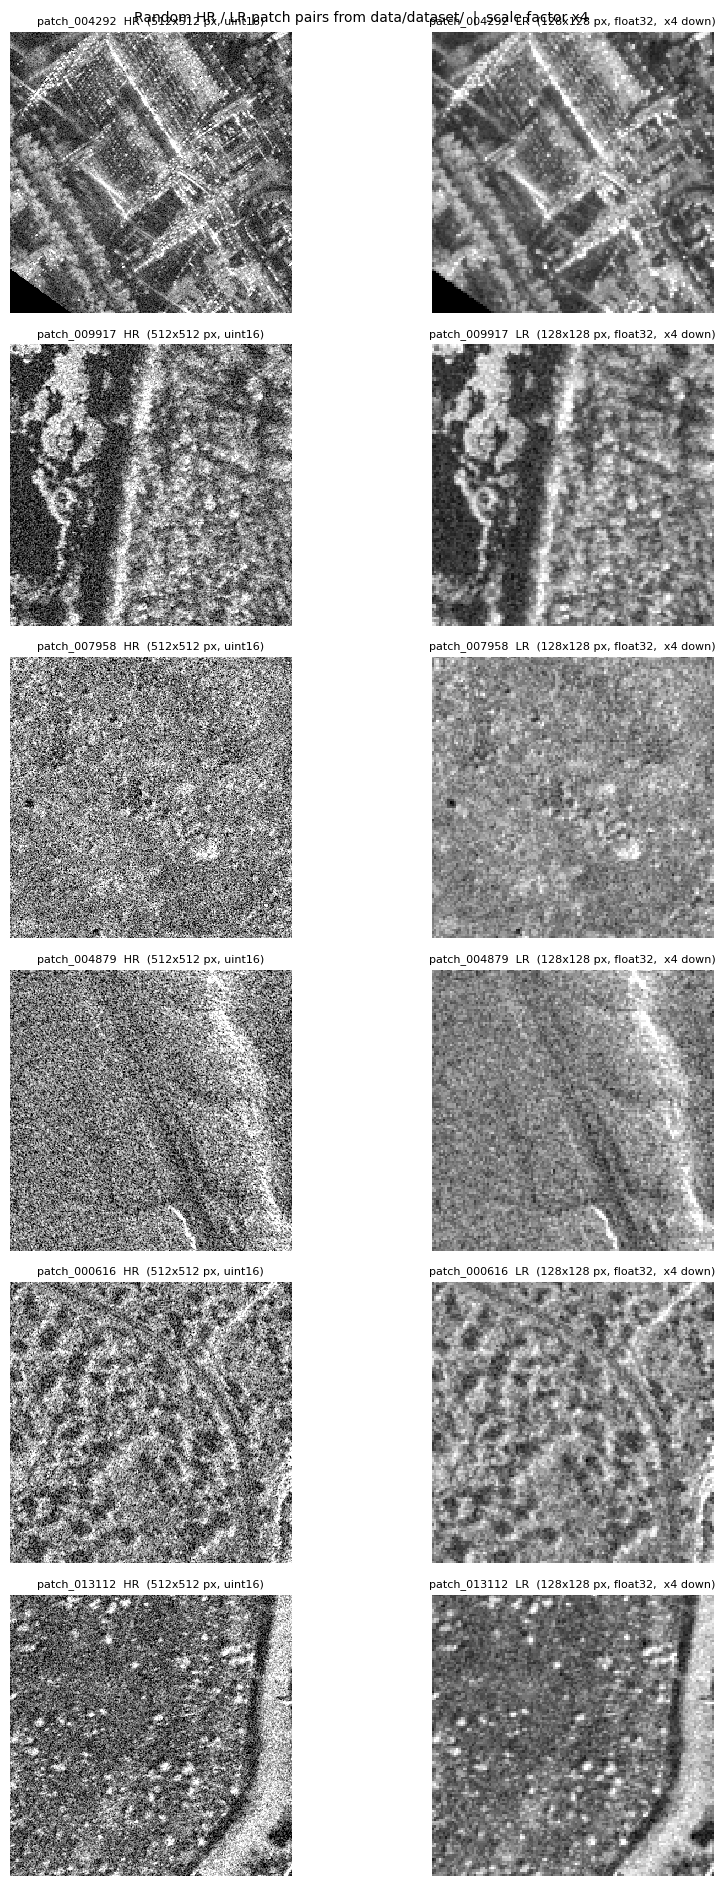

In [14]:
# ── Visual sanity check — show 6 random HR/LR pairs ──────────────────────────

def sar_log_scale(patch: np.ndarray, eps: float = 1e-3) -> np.ndarray:
    """Convert amplitude to dB-like log scale for display."""
    return 20.0 * np.log10(patch.astype(np.float32) + eps)


rng_viz  = np.random.default_rng(0)
n_show   = min(6, len(hr_files))
indices  = rng_viz.choice(len(hr_files), size=n_show, replace=False)

fig, axes = plt.subplots(n_show, 2, figsize=(10, 3.2 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for row_ax, idx in zip(axes, indices):
    hr_f = hr_files[idx]
    lr_f = OUT_DIR / hr_f.name.replace("_HR.tif", "_LR.tif")

    with rasterio.open(hr_f) as src:
        hr = src.read(1)
    with rasterio.open(lr_f) as src:
        lr = src.read(1)

    hr_log = sar_log_scale(hr)
    lr_log = sar_log_scale(lr)

    vmin = np.percentile(hr_log, 2)
    vmax = np.percentile(hr_log, 98)

    patch_name = hr_f.stem.replace("_HR", "")

    row_ax[0].imshow(hr_log, cmap='gray', vmin=vmin, vmax=vmax, interpolation='nearest')
    row_ax[0].set_title(f"{patch_name}  HR  ({hr.shape[0]}x{hr.shape[1]} px, uint16)", fontsize=8)
    row_ax[0].axis('off')

    row_ax[1].imshow(lr_log, cmap='gray', vmin=vmin, vmax=vmax, interpolation='nearest')
    row_ax[1].set_title(
        f"{patch_name}  LR  ({lr.shape[0]}x{lr.shape[1]} px, float32,  x{SCALE} down)",
        fontsize=8,
    )
    row_ax[1].axis('off')

fig.suptitle(
    f"Random HR / LR patch pairs from data/dataset/  |  scale factor x{SCALE}",
    fontsize=10,
)
plt.tight_layout()
plt.show()

In [15]:
# ── Verify one pair: read back and confirm shapes, dtypes, and coverage ───────

sample_hr_f = hr_files[0]
sample_lr_f = OUT_DIR / sample_hr_f.name.replace("_HR.tif", "_LR.tif")

with rasterio.open(sample_hr_f) as src:
    hr_arr = src.read(1)
    hr_tf  = src.transform
    hr_crs = src.crs

with rasterio.open(sample_lr_f) as src:
    lr_arr = src.read(1)
    lr_tf  = src.transform

print("HR patch")
print(f"  Shape  : {hr_arr.shape}")
print(f"  dtype  : {hr_arr.dtype}")
print(f"  Range  : [{hr_arr.min()}, {hr_arr.max()}]")
print(f"  Pixel  : {abs(hr_tf.a):.4f} m")
print(f"  CRS    : {hr_crs}")
print()
print("LR patch")
print(f"  Shape  : {lr_arr.shape}")
print(f"  dtype  : {lr_arr.dtype}")
print(f"  Range  : [{lr_arr.min():.1f}, {lr_arr.max():.1f}]")
print(f"  Pixel  : {abs(lr_tf.a):.4f} m  (= HR pixel x {SCALE})")
print()
assert hr_arr.shape[0] == PATCH_HR, "HR row mismatch"
assert hr_arr.shape[1] == PATCH_HR, "HR col mismatch"
assert lr_arr.shape[0] == PATCH_LR, "LR row mismatch"
assert lr_arr.shape[1] == PATCH_LR, "LR col mismatch"
assert round(abs(lr_tf.a) / abs(hr_tf.a)) == SCALE, "Pixel spacing ratio mismatch"
print("All assertions passed. Dataset is consistent.")

HR patch
  Shape  : (512, 512)
  dtype  : uint16
  Range  : [1, 23994]
  Pixel  : 0.3410 m
  CRS    : EPSG:32610

LR patch
  Shape  : (128, 128)
  dtype  : float32
  Range  : [110.2, 7202.9]
  Pixel  : 1.3639 m  (= HR pixel x 4)

All assertions passed. Dataset is consistent.


## Summary

| Property | Value |
|----------|-------|
| Total pairs | ~15,820 |
| HR size | 512 x 512 px, uint16 |
| LR size | 128 x 128 px, float32 |
| Scale factor | 4x (bicubic, anti-aliased) |
| File format | GeoTIFF, LZW compressed |